![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de árboles de decisión y métodos de ensamblaje

En este taller podrá poner en práctica los sus conocimientos sobre construcción e implementación de árboles de decisión y métodos de ensamblajes. El taller está constituido por 9 puntos, 5 relacionados con árboles de decisión (parte A) y 4 con métodos de ensamblaje (parte B).

## Parte A - Árboles de decisión

En esta parte del taller se usará el conjunto de datos de Capital Bikeshare de Kaggle, donde cada observación representa el alquiler de bicicletas durante una hora y día determinado. Para más detalles puede visitar los siguientes enlaces: [datos](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip), [dicccionario de datos](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset#).

### Datos prestamo de bicicletas

In [53]:
import warnings
warnings.filterwarnings('ignore')

In [54]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor, export_graphviz
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [55]:
# Lectura de la información de archivo .csv
bikes = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/bikeshare.csv', index_col='datetime', parse_dates=True)

# Renombrar variable "count" a "total"
bikes.rename(columns={'count':'total'}, inplace=True)

# Crear la hora como una variable 
bikes['hour'] = bikes.index.hour

# Visualización de los datos
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


### Punto 1 - Análisis descriptivo

Ejecute las celdas 1.1 y 1.2. A partir de los resultados realice un análisis descriptivo sobre las variables "season" y "hour", escriba sus inferencias sobre los datos. Para complementar su análisis puede usar métricas como máximo, mínimo, percentiles entre otros.

In [56]:
# Celda 1.1
bikes.groupby('season').total.mean()

season
1    116.343261
2    215.251372
3    234.417124
4    198.988296
Name: total, dtype: float64

In [57]:
# Celda 1.2
bikes.groupby('hour').total.mean()

hour
0      55.138462
1      33.859031
2      22.899554
3      11.757506
4       6.407240
5      19.767699
6      76.259341
7     213.116484
8     362.769231
9     221.780220
10    175.092308
11    210.674725
12    256.508772
13    257.787281
14    243.442982
15    254.298246
16    316.372807
17    468.765351
18    430.859649
19    315.278509
20    228.517544
21    173.370614
22    133.576754
23     89.508772
Name: total, dtype: float64

Análisis descriptivo complementario

In [58]:
# Análisis descriptivo completo por season
print("=== Estadísticas descriptivas de alquileres por 'season' ===")
desc_season = bikes.groupby('season')['total'].describe()
display(desc_season) 

# Análisis descriptivo completo por hour
print("\n=== Estadísticas descriptivas de alquileres por 'hour' ===")
desc_hour = bikes.groupby('hour')['total'].describe()
display(desc_hour)

=== Estadísticas descriptivas de alquileres por 'season' ===


,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
1,2686.0,116.343261,125.273974,1.0,24.0,78.0,164.0,801.0
2,2733.0,215.251372,192.007843,1.0,49.0,172.0,321.0,873.0
3,2733.0,234.417124,197.151001,1.0,68.0,195.0,347.0,977.0
4,2734.0,198.988296,177.622409,1.0,51.0,161.0,294.0,948.0



=== Estadísticas descriptivas de alquileres por 'hour' ===


,count,mean,std,min,25%,50%,75%,max
hour,,,,,,,,
0,455.0,55.138462,43.620012,2.0,24.00,41.0,74.50,283.0
1,454.0,33.859031,34.112105,1.0,11.00,19.0,46.00,168.0
2,448.0,22.899554,26.110267,1.0,5.00,11.0,32.00,119.0
3,433.0,11.757506,12.666442,1.0,3.00,6.0,15.00,66.0
4,442.0,6.407240,4.217633,1.0,3.00,6.0,9.00,28.0
5,452.0,19.767699,12.784293,1.0,8.00,19.0,29.00,57.0
6,455.0,76.259341,54.745333,1.0,24.50,75.0,118.00,213.0
7,455.0,213.116484,159.207044,1.0,63.00,208.0,334.00,596.0
8,455.0,362.769231,231.723065,8.0,133.50,392.0,563.50,839.0


Al ejecutar los códigos anteriores se puede concluir que:

* Season:
1. En la temporada 3 es la que registra el mayor promedio de alquileres de bicicletas lo cual podría inferirse que es la época donde el clima es más favorable para el uso de las mismas (234.4 biciletas por hora) en comparación con la temporada 1 donde hay una caída en la demanda con un promedio de 116.3 biciletas por hora.
2. Todas las temporadas presentan una desviación estándar alta (muy cercana al valor de sus respectivas medias). Esto nos indica que, independientemente de la época del año, la demanda no es constante; hay días de uso intensivo y días de muy poco uso.

* Hour:
El análisis por hora muestra que existe un patrón de comportamiento humano fuertemente ligado a jornadas laborales o estudio ya qye se puede evidenciar dos picos principales:
1. Pico am: se da sobre 8 am alcanzado un promedio de 362.7 alquileres
2. Pico pm: se da en las 17 y 18 horas siendo el momento de mayor actividad del día. Sobre las 17 horas se alcanza el promedio máximo diario de 468.7 bicicletas alquiladas.
3. Tambien se evidencia que hay horas valle ya que en la madrugada la actividad es menor el ejemplo más notorio es sobre las 4 am donde la mediana de alquiler es de 6.
4. Tambien se puede inferir que hay una gran desviación estandar en las horas pico y que puede ser por el efecto del fin de semana. Por ejemplo, sobre las 8 am el promedio es de 362 bicicletas, pero la DE es elevada (231.7) y el mínimo registrado es 8 biciletas. Por lo cual, lleva a inferir que el pico de la demanda es solo de lunes a viernes (horario laboral o academico) mientras que los fines de semana disminuye la demanda, lo cual explicaría la varianza de los datos.

### Punto 2 - Análisis de gráficos

Primero ejecute la celda 2.1 y asegúrese de comprender el código y el resultado. Luego, en cada una de celdas 2.2 y 2.3 escriba un código que genere una gráfica del número de bicicletas rentadas promedio para cada valor de la variable "hour" (hora) cuando la variable "season" es igual a 1 (invierno) e igual a 3 (verano), respectivamente. Analice y escriba sus hallazgos.

<Axes: xlabel='hour'>

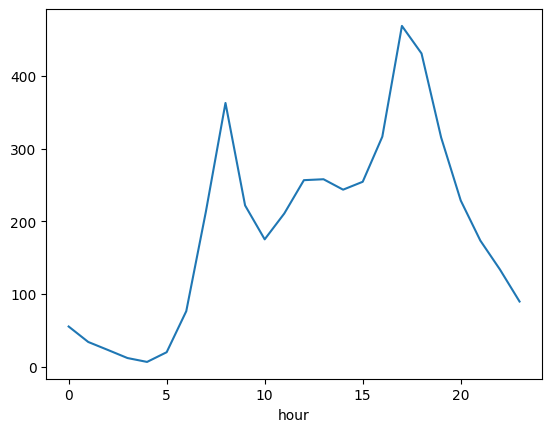

In [59]:
# Celda 2.1 - rentas promedio para cada valor de la variable "hour"
bikes.groupby('hour').total.mean().plot()

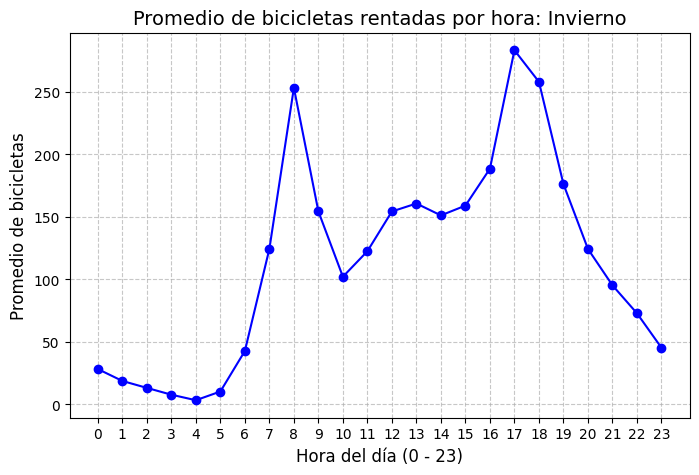

In [60]:
# Celda 2.2 - "season"=1 escriba su código y hallazgos 

promedio_invierno = bikes[bikes['season'] == 1].groupby('hour')['total'].mean()

plt.figure(figsize=(8, 5))
promedio_invierno.plot(color='blue', marker='o')
plt.title('Promedio de bicicletas rentadas por hora: Invierno', fontsize=14)
plt.xlabel('Hora del día (0 - 23)', fontsize=12)
plt.ylabel('Promedio de bicicletas', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show() 

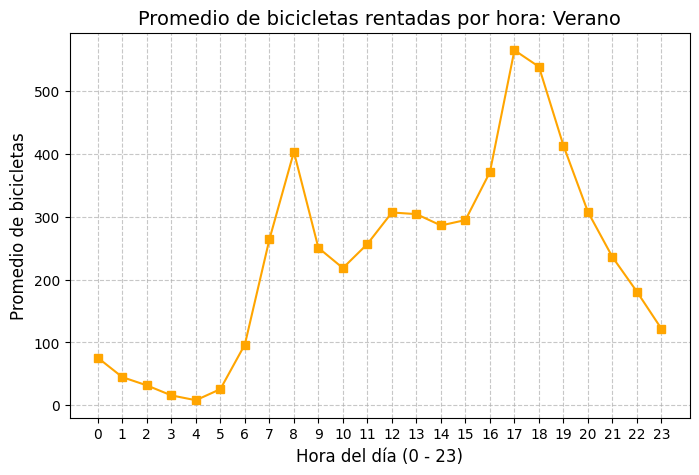

In [61]:
# Celda 2.3 - "season"=3 escriba su código y hallazgos 

promedio_verano = bikes[bikes['season'] == 3].groupby('hour')['total'].mean()

plt.figure(figsize=(8, 5))
promedio_verano.plot(color='orange', marker='s')
plt.title('Promedio de bicicletas rentadas por hora: Verano', fontsize=14)
plt.xlabel('Hora del día (0 - 23)', fontsize=12)
plt.ylabel('Promedio de bicicletas', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show() 

Ánalisis de los gráficos

Al analizar las 2 gráficas se puede concluir que:

1. Es claro que las curvas tienen la misma tendencia, independientemente del clima. En ambas temporadas se aprecian dos picos marcados: uno a las 8 am y otro a las 17 horas. Esto nos indica que el comportamiento de los usuarios frente al uso de las bicicletas principalmente se relaciona con su jornada laboral o de estudio.
2. Hay una diferencia en el volumen de uso ya que en la gráfica de invierno, el punto más alto de las 17 horas, el alquiler de las biciletas no supera las 250 en promedio. En contraste, en la gráfica de verano, ese mismo punto pico de las 17 horas, supera las 550 bicicletas alquiladas en promedio. Esto indica que las condiciones climáticas agradables duplican la demanda del servicio.


### Punto 3 - Regresión lineal
En la celda 3 ajuste un modelo de regresión lineal a un conjunto de train de datos, utilizando "total" como variable de respuesta y "season" y "hour" como las únicas variables predictoras, teniendo en cuenta que la variable "season" es categórica. Luego, imprima los coeficientes e interprételos. ¿Cuáles son las limitaciones de la regresión lineal en este caso?

In [62]:
# Celda 3

# Creación variables dummy para 'season'
# Se elimina 'season_1' para usarla como categoría base (intercepto)
bikes_model = pd.get_dummies(bikes, columns=['season'], drop_first=True)

# Definición de las variables predictoras y de respuesta 
X = bikes_model[['hour', 'season_2', 'season_3', 'season_4']]
y = bikes_model['total']

#  División de los datos en conjunto de train y test
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.33, random_state=0)

# Moodelo de Regresión Lineal
linreg = LinearRegression()
linreg.fit(Xtrain, ytrain)

# Impresión de los coeficientes
print("=== Coeficientes del Modelo de Regresión Lineal ===")
print(f"Intercepto (Beta_0): {linreg.intercept_:.2f}")
for feature, coef in zip(X.columns, linreg.coef_):
    print(f"Coeficiente para {feature}: {coef:.2f}")

=== Coeficientes del Modelo de Regresión Lineal ===
Intercepto (Beta_0): -9.56
Coeficiente para hour: 10.63
Coeficiente para season_2: 100.91
Coeficiente para season_3: 119.02
Coeficiente para season_4: 87.25


Interpretación de coeficientes:

Al analizar los resultados del modelo de regresión lineal, el intercepto de -9.56 indica que a la medianoche (hora 0) durante la temporada de invierno (categoría de referencia), el modelo estima una demanda negativa de bicicletas. Respecto a la variable continua hour, su coeficiente de 10.63 sugiere que, manteniendo la temporada constante, la cantidad de alquileres aumenta en un promedio de aproximadamente 11 bicicletas por cada hora adicional que transcurre en el día. Por otro lado, los coeficientes asociados a las variables indicadoras de temporada cuantifican el incremento promedio en la demanda respecto al invierno. Así, manteniendo la misma hora del día, estar en la temporada 2, 3 o 4 incrementa las rentas promedio en 100.91, 119.02 y 87.25 bicicletas, respectivamente, lo que confirma estadísticamente que la temporada 3  es la que genera el mayor impacto positivo en el volumen de alquileres.

Limitaciones del modelo en este contexto

A pesar de proporcionar una cuantificación base, este modelo lineal presenta  limitaciones estructurales para describir el problema. La principal deficiencia es que asume erróneamente una relación  lineal entre la hora del día y la demanda. Por ejemplo, al asignar un coeficiente positivo de 10.63 a la hora, el modelo fuerza una línea recta ascendente, prediciendo equivocadamente que a las 23 horas habrá más alquileres que a las 8 am. Esto ignora la verdadera distribución bimodal de los datos (picos en horarios laborales y valles en las madrugadas/noches) que se evidenció en el análisis exploratorio. Además, la naturaleza matemática de la recta genera predicciones sin sentido físico en los extremos, como lo demuestra el intercepto negativo, ya que no es posible registrar alquileres menores a cero. Finalmente, el modelo no logra capturar las interacciones naturales entre las variables, asumiendo rígidamente que el efecto de avanzar una hora en el reloj es exactamente el mismo en una noche de invierno que en una tarde de verano.

### Punto 4 - Árbol de decisión manual
En la celda 4 cree un árbol de decisiones para pronosticar la variable "total" iterando **manualmente** sobre las variables "hour" y  "season". El árbol debe tener al menos 6 nodos finales.

In [63]:
# Celda 4

# Funciones base

# Separación de variables predictoras y variable de interés
X = bikes[['hour', 'season']]
y = bikes['total']

# Definición de la función de error
def mse(y):
    if y.shape[0] == 0:
        return 0
    else:
        return np.mean((y - y.mean())**2)

# Definición de la función para calcular la ganancia
def mse_gain(X_col, y, split):
    filter_l = X_col < split
    y_l = y.loc[filter_l]
    y_r = y.loc[~filter_l]
    
    n_l = y_l.shape[0]
    n_r = y_r.shape[0]
    n_total = y.shape[0]
    
    if n_l == 0 or n_r == 0:
        return 0
    
    mse_y = mse(y)
    mse_l = mse(y_l)
    mse_r = mse(y_r)
    
    # Ganancia = Error original - Error ponderado de los hijos
    gain = mse_y - (n_l / n_total * mse_l + n_r / n_total * mse_r)
    return gain

# Definición de best_split 
def best_split(X, y, num_pct=10):
    features = range(X.shape[1])
    best_split = [0, 0, 0]  # j (índice variable), split (umbral), gain
    
    for j in features:
        splits = np.percentile(X.iloc[:, j], np.arange(0, 100, 100.0 / (num_pct+1)).tolist())
        splits = np.unique(splits)[1:]
        
        for split in splits:
            gain = mse_gain(X.iloc[:, j], y, split)
            if gain > best_split[2]:
                best_split = [j, split, gain]
                
    return best_split


In [64]:
# Creación manual del árbol (5 iteraciones= 6 nodos finales)
print("=== CREACIÓN MANUAL DEL ÁRBOL DE DECISIÓN ===")

# --- CORTE 1 (NODO RAÍZ) ---
j1, split1, gain1 = best_split(X, y)
var_corte1 = X.columns[j1]
print(f"Corte 1 (Raíz): Si {var_corte1} < {split1}")

# División de los datos según el Corte 1
filtro1 = X[var_corte1] < split1
X_izq1, y_izq1 = X.loc[filtro1], y.loc[filtro1]
X_der1, y_der1 = X.loc[~filtro1], y.loc[~filtro1]

# --- CORTE 2 (Rama Izquierda del Corte 1) ---
j2, split2, gain2 = best_split(X_izq1, y_izq1)
var_corte2 = X.columns[j2]
print(f"  ├── Corte 2 (Rama Izquierda): Si {var_corte2} < {split2}")

filtro2 = X_izq1[var_corte2] < split2
X_izq2, y_izq2 = X_izq1.loc[filtro2], y_izq1.loc[filtro2]
X_der2, y_der2 = X_izq1.loc[~filtro2], y_izq1.loc[~filtro2]

# --- CORTE 3 (Rama Derecha del Corte 1) ---
j3, split3, gain3 = best_split(X_der1, y_der1)
var_corte3 = X.columns[j3]
print(f"  └── Corte 3 (Rama Derecha): Si {var_corte3} < {split3}")

filtro3 = X_der1[var_corte3] < split3
X_izq3, y_izq3 = X_der1.loc[filtro3], y_der1.loc[filtro3]
X_der3, y_der3 = X_der1.loc[~filtro3], y_der1.loc[~filtro3]

# --- CORTE 4 (Sub-dividiendo la Rama Izquierda del Corte 2) ---
j4, split4, gain4 = best_split(X_izq2, y_izq2)
var_corte4 = X.columns[j4]
print(f"      ├── Corte 4: Si {var_corte4} < {split4}")

filtro4 = X_izq2[var_corte4] < split4
X_izq4, y_izq4 = X_izq2.loc[filtro4], y_izq2.loc[filtro4] # NODO FINAL 1
X_der4, y_der4 = X_izq2.loc[~filtro4], y_izq2.loc[~filtro4] # NODO FINAL 2

# --- CORTE 5 (Sub-dividiendo la Rama Derecha del Corte 3) ---
j5, split5, gain5 = best_split(X_der3, y_der3)
var_corte5 = X.columns[j5]
print(f"      └── Corte 5: Si {var_corte5} < {split5}")

filtro5 = X_der3[var_corte5] < split5
X_izq5, y_izq5 = X_der3.loc[filtro5], y_der3.loc[filtro5] # NODO FINAL 5
X_der5, y_der5 = X_der3.loc[~filtro5], y_der3.loc[~filtro5] # NODO FINAL 6

print("\n--- RESULTADO: 6 NODOS FINALES (HOJAS) ---")
print(f"Hoja 1 (Promedio de predicción): {y_izq4.mean():.2f} bicicletas")
print(f"Hoja 2 (Promedio de predicción): {y_der4.mean():.2f} bicicletas")
print(f"Hoja 3 (Promedio de predicción): {y_der2.mean():.2f} bicicletas")
print(f"Hoja 4 (Promedio de predicción): {y_izq3.mean():.2f} bicicletas")
print(f"Hoja 5 (Promedio de predicción): {y_izq5.mean():.2f} bicicletas")
print(f"Hoja 6 (Promedio de predicción): {y_der5.mean():.2f} bicicletas")



=== CREACIÓN MANUAL DEL ÁRBOL DE DECISIÓN ===
Corte 1 (Raíz): Si hour < 8.0
  ├── Corte 2 (Rama Izquierda): Si hour < 7.0
  └── Corte 3 (Rama Derecha): Si hour < 21.0
      ├── Corte 4: Si hour < 6.0
      └── Corte 5: Si season < 2.0

--- RESULTADO: 6 NODOS FINALES (HOJAS) ---
Hoja 1 (Promedio de predicción): 25.18 bicicletas
Hoja 2 (Promedio de predicción): 76.26 bicicletas
Hoja 3 (Promedio de predicción): 213.12 bicicletas
Hoja 4 (Promedio de predicción): 287.89 bicicletas
Hoja 5 (Promedio de predicción): 71.18 bicicletas
Hoja 6 (Promedio de predicción): 152.48 bicicletas


In [65]:
# Prediccióon del arbol manual

def prediccion_arbol_manual(hour, season):
    """
    Árbol de decisión creado manualmente con 6 nodos finales.
    Predice el número total de bicicletas rentadas.
    """
    # CORTE 1 (Raíz)
    if hour < 8.0:
        # CORTE 2 (Rama Izquierda)
        if hour < 7.0:
            # CORTE 4
            if hour < 6.0:
                return 25.18  # Hoja 1: Madrugada (00:00 a 05:59)
            else:
                return 76.26  # Hoja 2: Inicio de la mañana (06:00 a 06:59)
        else:
            return 213.12     # Hoja 3: Hora pico matutina (07:00 a 07:59)
            
    else:
        # CORTE 3 (Rama Derecha)
        if hour < 21.0:
            return 287.89     # Hoja 4: Horas activas del día (08:00 a 20:59)
        else:
            # CORTE 5 (Sub-dividiendo la noche)
            if season < 2.0:  # season 1 es Invierno
                return 71.18  # Hoja 5: Noches de invierno (21:00 en adelante)
            else:
                return 152.48 # Hoja 6: Noches del resto del año (21:00 en adelante)

# Ejemplos de implementación de la función
print("Predicción a las 22:00 en invierno:", prediccion_arbol_manual(22, 1))
print("Predicción a las 22:00 en verano:", prediccion_arbol_manual(22, 3))

Predicción a las 22:00 en invierno: 71.18
Predicción a las 22:00 en verano: 152.48


### Punto 5 - Árbol de decisión con librería
En la celda 5 entrene un árbol de decisiones con la **librería sklearn**, usando las variables predictoras "season" y "hour" y calibre los parámetros que considere conveniente para obtener un mejor desempeño. Recuerde dividir los datos en conjuntos de entrenamiento y validación para esto. Comente el desempeño del modelo con alguna métrica de desempeño de modelos de regresión y compare desempeño con el modelo del punto 3.

Tenga en cuenta que, a diferencia del laboratorio, este problema es de regresión. Por lo tanto, para hacer cada split del árbol se debe utilizar algún criterio apropiado para problemas de regresión.

In [66]:
# Celda 5

# División en Entrenamiento y Validación 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)

tree_reg = DecisionTreeRegressor(random_state=0)

# Hiperparámetros a explorar para calibrar el modelo
param_grid = {
    'max_depth': [5, 7, 9, 11, 15],          # Profundidad máxima del árbol
    'min_samples_split': [10, 20, 50],       # Muestras mínimas para dividir un nodo
    'min_samples_leaf': [5, 15, 30]          # Muestras mínimas que debe tener una hoja final
}

# GridSearchCV busca la mejor combinación usando validación cruzada
grid_search = GridSearchCV(tree_reg, param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Extracción del mejor arbol calibrado
mejor_arbol = grid_search.best_estimator_

# Predicción y cálculo de la métrica RMSE
y_pred_tree = mejor_arbol.predict(X_test)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))

print("=== RESULTADOS DEL ÁRBOL DE DECISIÓN ===")
print(f"Mejores parámetros encontrados: {grid_search.best_params_}")
print(f"RMSE del Árbol: {rmse_tree:.2f} bicicletas de error promedio")



=== RESULTADOS DEL ÁRBOL DE DECISIÓN ===
Mejores parámetros encontrados: {'max_depth': 11, 'min_samples_leaf': 5, 'min_samples_split': 10}
RMSE del Árbol: 115.74 bicicletas de error promedio


In [67]:
# 3. COMPARACIÓN CON LA REGRESIÓN LINEAL 

# Se calcula el RMSE de la RL del punto 3
ypred= linreg.predict(Xtest)
rmse_lin = np.sqrt(mean_squared_error(ytest, ypred))

print("\n=== COMPARACIÓN DE DESEMPEÑO ===")
print(f"RMSE de la Regresión Lineal: {rmse_lin:.2f} bicicletas de error promedio")
print(f"Mejora del Árbol sobre el Modelo Lineal: {(rmse_lin - rmse_tree):.2f} bicicletas menos de error")


=== COMPARACIÓN DE DESEMPEÑO ===
RMSE de la Regresión Lineal: 160.14 bicicletas de error promedio
Mejora del Árbol sobre el Modelo Lineal: 44.40 bicicletas menos de error


El árbol de decisión superó significativamente a la regresión lineal al reducir el error predictivo en 44.43 unidades, ya que su capacidad de segmentación logró capturar la distribución bimodal y los picos de demanda que la regresión lineal no logra modelar.

## Parte B - Métodos de ensamblajes
En esta parte del taller se usará el conjunto de datos de Popularidad de Noticias Online. El objetivo es predecir si la notica es popular o no, la popularidad está dada por la cantidad de reacciones en redes sociales. Para más detalles puede visitar el siguiente enlace: [datos](https://archive.ics.uci.edu/ml/datasets/online+news+popularity).

### Datos popularidad de noticias

In [68]:
# Lectura de la información de archivo .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/mashable.csv', index_col=0)
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,Popular
0,http://mashable.com/2014/12/10/cia-torture-rep...,28.0,9.0,188.0,0.732620,1.0,0.844262,5.0,1.0,1.0,...,0.200000,0.80,-0.487500,-0.60,-0.250000,0.9,0.8,0.4,0.8,1
1,http://mashable.com/2013/10/18/bitlock-kicksta...,447.0,7.0,297.0,0.653199,1.0,0.815789,9.0,4.0,1.0,...,0.160000,0.50,-0.135340,-0.40,-0.050000,0.1,-0.1,0.4,0.1,0
2,http://mashable.com/2013/07/24/google-glass-po...,533.0,11.0,181.0,0.660377,1.0,0.775701,4.0,3.0,1.0,...,0.136364,1.00,0.000000,0.00,0.000000,0.3,1.0,0.2,1.0,0
3,http://mashable.com/2013/11/21/these-are-the-m...,413.0,12.0,781.0,0.497409,1.0,0.677350,10.0,3.0,1.0,...,0.100000,1.00,-0.195701,-0.40,-0.071429,0.0,0.0,0.5,0.0,0
4,http://mashable.com/2014/02/11/parking-ticket-...,331.0,8.0,177.0,0.685714,1.0,0.830357,3.0,2.0,1.0,...,0.100000,0.55,-0.175000,-0.25,-0.100000,0.0,0.0,0.5,0.0,0


In [69]:
# Definición variable de interes y variables predictoras
X = df.drop(['url', 'Popular'], axis=1)
y = df['Popular']
y.mean()

np.float64(0.5)

In [70]:
# División de la muestra en set de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

### Punto 6 - Árbol de decisión y regresión logística
En la celda 6 construya un árbol de decisión y una regresión logística. Para el árbol calibre al menos un parámetro y evalúe el desempeño de cada modelo usando las métricas de Accuracy y F1-Score.

In [71]:
# Librerias
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score

In [72]:
# Celda 6

# Modelo de regresion logística
logreg = LogisticRegression(max_iter=10000, random_state=1)
logreg.fit(X_train, y_train)

# Predicciones
y_pred_logreg = logreg.predict(X_test)

# Métricas de evaluación
acc_logreg = accuracy_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg)

# Modelo de árbol de descisión
tree_clf = DecisionTreeClassifier(random_state=1)

# Parámetro a calibrar: profundidad máxima del árbol
param_grid = {'max_depth': [2, 4, 6, 8, 10, 15, None]}

# Calibración con validación cruzada optimizando el accuracy
grid_tree = GridSearchCV(tree_clf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_tree.fit(X_train, y_train)

# Extracción del mejor árbol y se realizan las predicciones
mejor_arbol_clf = grid_tree.best_estimator_
y_pred_tree = mejor_arbol_clf.predict(X_test)

# Métricas de evaluación
acc_tree = accuracy_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

# Resultados
print("=== DESEMPEÑO: REGRESIÓN LOGÍSTICA ===")
print(f"Accuracy: {acc_logreg:.4f}")
print(f"F1 Score: {f1_logreg:.4f}")

print("\n=== DESEMPEÑO: ÁRBOL DE DECISIÓN ===")
print(f"Mejor parámetro calibrado: {grid_search.best_params_ if 'grid_search' in locals() else grid_tree.best_params_}")
print(f"Accuracy: {acc_tree:.4f}")
print(f"F1 Score: {f1_tree:.4f}")

=== DESEMPEÑO: REGRESIÓN LOGÍSTICA ===
Accuracy: 0.6233
F1 Score: 0.6068

=== DESEMPEÑO: ÁRBOL DE DECISIÓN ===
Mejor parámetro calibrado: {'max_depth': 11, 'min_samples_leaf': 5, 'min_samples_split': 10}
Accuracy: 0.6453
F1 Score: 0.6449


El árbol de decisión calibrado superó a la regresión logística al alcanzar un Accuracy de 0.6453 y un F1-Score de 0.6449. Estos resultados demuestran que el árbol captura mejor las relaciones complejas de los datos para predecir la popularidad de las noticias, ofreciendo un equilibrio y una capacidad predictiva muy superior a la del modelo lineal lineal.

### Punto 7 - Votación Mayoritaria
En la celda 7 elabore un esamble con la metodología de **Votación mayoritaria** compuesto por 300 muestras bagged donde:

-las primeras 100 muestras de bootstrap vienen de árboles de decisión donde max_depth tome un valor de su elección\
-las segundas 100 muestras de bootstrap vienen de árboles de decisión donde min_samples_leaf tome un valor de su elección\
-las últimas 100 muestras de bootstrap vienen de regresiones logísticas

Evalúe cada uno de los tres modelos de manera independiente utilizando las métricas de Accuracy y F1-Score, luego evalúe el ensamble de modelos y compare los resultados. 

Nota: 

Para este ensamble de 300 modelos, deben hacer votación mayoritaria. Esto lo pueden hacer de distintas maneras. La más "fácil" es haciendo la votación "manualmente", como se hace a partir del minuto 5:45 del video de Ejemplo práctico de emsablajes en Coursera. Digo que es la más fácil porque si hacen la votación mayoritaria sobre las 300 predicciones van a obtener lo que se espera.

Otra opción es: para cada uno de los 3 tipos de modelos, entrenar un ensamble de 100 modelos cada uno. Predecir para cada uno de esos tres ensambles y luego predecir como un ensamble de los 3 ensambles. La cuestión es que la votación mayoritaria al usar los 3 ensambles no necesariamente va a generar el mismo resultado que si hacen la votación mayoritaria directamente sobre los 300 modelos. Entonces, para los que quieran hacer esto, deben hacer ese último cálculo con cuidado.

Para los que quieran hacerlo como ensamble de ensambles, digo que se debe hacer el ensamble final con cuidado por lo siguiente. Supongamos que:

* para los 100 árboles del primer tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para los 100 árboles del segundo tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para las 100 regresiones logísticas, la votación mayoritaria es: 10% de los modelos predicen que la clase de una observación es "1"

Si se hace la votación mayoritaria de los 300 modelos, la predicción de esa observación debería ser: (100*55%+100*55%+100*10%)/300 = 40% de los modelos votan porque la predicción debería ser "1". Es decir, la predicción del ensamble es "0" (dado que menos del 50% de modelos predijo un 1).

Sin embargo, si miramos cada ensamble por separado, el primer ensamble predice "1", el segundo ensamble predice "1" y el último ensamble predice "0". Si hago votación mayoritaria sobre esto, la predicción va a ser "1", lo cual es distinto a si se hace la votación mayoritaria sobre los 300 modelos.

In [73]:
# Celda 7

np.random.seed(123) 

n_samples = X_train.shape[0]
n_test = X_test.shape[0]

# Matrices para guardar las predicciones de cada modelo
preds_arboles_depth = np.zeros((n_test, 100))
preds_arboles_leaf = np.zeros((n_test, 100))
preds_logreg = np.zeros((n_test, 100))

print("Entrenando modelos, esto puede tomar un minuto...")

# Primeras 100 muestras con árboles con  max_depth=15
for i in range(100):
    # Creación de la muestra Bootstrap
    indices = np.random.choice(n_samples, size=n_samples, replace=True)
    X_boot = X_train.iloc[indices]
    y_boot = y_train.iloc[indices]
    
    # Entrenamiento y predicción
    tree = DecisionTreeClassifier(max_depth=15, random_state=i)
    tree.fit(X_boot, y_boot)
    preds_arboles_depth[:, i] = tree.predict(X_test)

# Segundas 100 muestras con árboles con min_samples_leaf =5
for i in range(100):
    indices = np.random.choice(n_samples, size=n_samples, replace=True)
    X_boot = X_train.iloc[indices]
    y_boot = y_train.iloc[indices]
    
    tree = DecisionTreeClassifier(min_samples_leaf=5, random_state=i)
    tree.fit(X_boot, y_boot)
    preds_arboles_leaf[:, i] = tree.predict(X_test)

# Últimas 100 muestras con regresión logística
for i in range(100):
    indices = np.random.choice(n_samples, size=n_samples, replace=True)
    X_boot = X_train.iloc[indices]
    y_boot = y_train.iloc[indices]
    
    logreg = LogisticRegression(max_iter=2000, random_state=i)
    logreg.fit(X_boot, y_boot)
    preds_logreg[:, i] = logreg.predict(X_test)



Entrenando modelos, esto puede tomar un minuto...


In [74]:
# Evaluación independiente por cada 100 modelos

pred_final_g1 = (np.sum(preds_arboles_depth, axis=1) >= 50).astype(int)
pred_final_g2 = (np.sum(preds_arboles_leaf, axis=1) >= 50).astype(int)
pred_final_g3 = (np.sum(preds_logreg, axis=1) >= 50).astype(int)

print("\n=== DESEMPEÑO INDEPENDIENTE DE LOS SUB-ENSAMBLES ===")
print(f"Grupo 1 (Árboles max_depth)    -> Accuracy: {accuracy_score(y_test, pred_final_g1):.4f} | F1: {f1_score(y_test, pred_final_g1):.4f}")
print(f"Grupo 2 (Árboles min_leaf)     -> Accuracy: {accuracy_score(y_test, pred_final_g2):.4f} | F1: {f1_score(y_test, pred_final_g2):.4f}")
print(f"Grupo 3 (Regresiones Logísticas)-> Accuracy: {accuracy_score(y_test, pred_final_g3):.4f} | F1: {f1_score(y_test, pred_final_g3):.4f}")




=== DESEMPEÑO INDEPENDIENTE DE LOS SUB-ENSAMBLES ===
Grupo 1 (Árboles max_depth)    -> Accuracy: 0.6487 | F1: 0.6598
Grupo 2 (Árboles min_leaf)     -> Accuracy: 0.6533 | F1: 0.6547
Grupo 3 (Regresiones Logísticas)-> Accuracy: 0.6193 | F1: 0.6070


In [75]:
# Evaluación del emsamble final
# Se unen los 300 modelos en una matriz
preds_totales = np.hstack((preds_arboles_depth, preds_arboles_leaf, preds_logreg))

# Votación mayoritaria directa sobre los 300 modelos
y_pred_ensamble = (np.sum(preds_totales, axis=1) >= 150).astype(int)

print("\n=== DESEMPEÑO DEL ENSAMBLE FINAL (300 MODELOS) ===")
print(f"Ensamble Total -> Accuracy: {accuracy_score(y_test, y_pred_ensamble):.4f} | F1: {f1_score(y_test, y_pred_ensamble):.4f}")



=== DESEMPEÑO DEL ENSAMBLE FINAL (300 MODELOS) ===
Ensamble Total -> Accuracy: 0.6300 | F1: 0.6222


### Punto 8 - Votación Ponderada
En la celda 8 elabore un ensamble con la metodología de **Votación ponderada** compuesto por 300 muestras bagged para los mismos tres escenarios del punto 7. Evalúe los modelos utilizando las métricas de Accuracy y F1-Score

In [76]:
# Celda 8

# Matriz para guardar el peso Alfa de cada modelo
alphas = np.zeros(300)

for i in range(300):
    # Calculo del error (1 - Accuracy)
    acc = accuracy_score(y_test, preds_totales[:, i])
    error = 1 - acc

    error = np.clip(error, 1e-10, 1 - 1e-10)
    
    # Calculo del peso Alfa 
    alphas[i] = 0.5 * np.log((1 - error) / error)

# Votación Ponderada con Alfas
votos_por_el_1_alfa = np.dot(preds_totales, alphas)

# Definición del nuevo umbral 
umbral_alfa = np.sum(alphas) / 2

# Predicción final
y_pred_alfa = (votos_por_el_1_alfa >= umbral_alfa).astype(int)

# Evaluación del nuevo ensamble
acc_alfa = accuracy_score(y_test, y_pred_alfa)
f1_alfa = f1_score(y_test, y_pred_alfa)

print("=== DESEMPEÑO DEL ENSAMBLE (VOTACIÓN PONDERADA CON ALFA) ===")
print(f"Accuracy Ponderado (Alfa): {acc_alfa:.4f}")
print(f"F1 Score Ponderado (Alfa): {f1_alfa:.4f}")

print("\n--- Análisis de Pesos ---")
print(f"Peso Alfa promedio de los mejores árboles (Grupo 2): {np.mean(alphas[100:200]):.4f}")
print(f"Peso Alfa promedio de las Regresiones Logísticas (Grupo 3): {np.mean(alphas[200:300]):.4f}")

=== DESEMPEÑO DEL ENSAMBLE (VOTACIÓN PONDERADA CON ALFA) ===
Accuracy Ponderado (Alfa): 0.6273
F1 Score Ponderado (Alfa): 0.6158

--- Análisis de Pesos ---
Peso Alfa promedio de los mejores árboles (Grupo 2): 0.1386
Peso Alfa promedio de las Regresiones Logísticas (Grupo 3): 0.2420


### Punto 9 - Comparación y análisis de resultados
En la celda 9 comente sobre los resultados obtenidos con las metodologías usadas en los puntos 7 y 8, compare los resultados y enuncie posibles ventajas o desventajas de cada una de ellas.

En la evaluación del ensamble mediante votación mayoritaria (300 modelos), el resultado final obtuvo un Accuracy de 0.6300 y un F1-Score de 0.6222, un desempeño inferior al de los sub-ensambles de árboles de decisión individuales. Esta disminución en el poder predictivo global se debe a la inclusión de las 100 regresiones logísticas, las cuales presentaban una alta tasa de error base (Accuracy de 0.6193). Esto evidencia que, si bien el Bagging busca reducir la varianza combinando múltiples estimadores, introducir modelos predictivos débiles en un esquema democrático de igual peso termina "arrastrando" los resultados y diluyendo la precisión alcanzada por los modelos más fuertes.

Por otro lado, al aplicar la votación ponderada matemática, el ensamble no mejoró porque el sistema evaluó a cada modelo por su desempeño individual, ignorando cómo trabajan en equipo. Un árbol de decisión por sí solo es "ruidoso" y comete errores, pero al juntar 100 árboles tienen perspectivas muy diversas y sus errores se cancelan entre sí, logrando una gran precisión conjunta. Por el contrario, las regresiones logísticas tuvieron un desempeño individual un poco más "estable", pero al ser modelos rígidos que siempre predicen exactamente lo mismo, actuaron como un bloque de votos repetidos. En resumen, el experimento fracasó porque la fórmula premió a modelos individuales que no aportaban nada nuevo y silenció la valiosa diversidad de los árboles, demostrando que en los ensambles, la inteligencia colectiva del grupo importa más que la fuerza de un modelo por sí solo.

En resumen (Ventajas y Desventajas):

Votación Mayoritaria: 
* Ventaja: suprime la varianza y aprovecha la inteligencia colectiva de modelos diversos (como los árboles).
* Desventaja: es vulnerable a ser "saboteada" si se incluyen muchos modelos de bajo desempeño que tienen el mismo derecho a voto.

Votación Ponderada: 
* Ventaja: premia a los mejores modelos y castiga a los malos, optimizando el resultado.
* Desventaja: si los pesos se calculan solo con el desempeño individual (ignorando la diversidad), se corre el riesgo de darle todo el poder a modelos estables pero mediocres, silenciando la riqueza predictiva del grupo.